# Portfolio Optimization using SLSQP
A Jupyter notebook for exploring portfolio data and performing custom portfolio optimization using SLSQP, including a 10% maximum constraint on risk-free assets.

In [3]:
import pandas as pd
import numpy as np
import scipy.optimize as sco
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 1. Load Required Libraries
Import essential libraries including pandas for data manipulation, numpy for numerical operations, scipy.optimize for the SLSQP algorithm, and matplotlib/seaborn for visualization.

## 2. Load and Inspect Training Data
Read the provided CSV file `./hackaton-uam-paulo_prod_long_sharpe_u60_20260512_v1_train_dataset.csv`, display the first few rows, and check data types and missing values.

In [8]:
# Assume the file contains timeseries data for the 60 assets, likely with a Date index.
file_path = "/Users/adham/Documents/sorbonne manhag/MASTER ISI/Adham/S2_UAM/Capital markets/hackaton-uam-paulo_prod_long_sharpe_u60_20260512_v1_train_dataset.csv"
try:
    # Use read_excel since the file is actually an Excel workbook despite the .csv extension
    df = pd.read_excel(file_path, index_col=0)
    display(df.head())
    print("\nData Info:")
    display(df.info())
    print("\nMissing Values:")
    display(df.isnull().sum().max())
except FileNotFoundError:
    print(f"File not found at: {file_path}")
    print("Please make sure the path is correct or place the file in the working directory.")

,2,3,4,5,6,7,8,9,10,11,...,51,52,53,54,55,56,57,58,59,60
1,,,,,,,,,,,,,,,,,,,,,
-0.028988,0.000000,0.011857,-0.052465,-0.044951,-0.001556,-0.061189,-0.022658,-0.070095,-0.078670,-0.063281,...,-0.011112,-0.060292,-0.001453,-0.032199,-0.037156,0.000000,-0.032860,-0.050789,-0.038136,-0.019340
-0.001839,-0.009662,0.036648,0.002373,0.028330,0.060441,0.010914,0.042820,0.067410,-0.006427,0.039413,...,0.008345,0.015417,0.000000,0.046082,-0.022330,0.025879,0.032860,-0.010135,-0.020619,0.053082
0.034392,0.013261,0.005665,0.030049,0.090729,0.010211,0.082024,0.020742,0.043399,0.013692,0.047179,...,0.024625,-0.019566,0.059256,0.000000,0.074569,0.012694,-0.005092,0.043195,0.010854,0.050405
0.010620,0.022500,0.013097,0.072178,-0.003407,0.028614,-0.026600,0.055147,0.109022,0.136664,-0.004619,...,0.042334,0.008534,-0.006873,-0.024188,0.038184,0.007181,-0.007412,0.017728,0.072845,-0.002939
-0.007067,0.024293,-0.003725,-0.017852,-0.040040,-0.014205,-0.035274,-0.038666,0.098296,-0.011009,-0.003478,...,0.010310,0.014065,0.023178,0.010305,-0.005781,0.008904,-0.005327,-0.032470,-0.018416,-0.014080



Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1758 entries, -0.02898784533307892 to -0.00450591255877311
Data columns (total 59 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   2       1758 non-null   float64
 1   3       1758 non-null   float64
 2   4       1758 non-null   float64
 3   5       1758 non-null   float64
 4   6       1758 non-null   float64
 5   7       1758 non-null   float64
 6   8       1758 non-null   float64
 7   9       1758 non-null   float64
 8   10      1758 non-null   float64
 9   11      1758 non-null   float64
 10  12      1758 non-null   float64
 11  13      1758 non-null   float64
 12  14      1758 non-null   float64
 13  15      1758 non-null   float64
 14  16      1758 non-null   float64
 15  17      1758 non-null   float64
 16  18      1758 non-null   float64
 17  19      1758 non-null   float64
 18  20      1758 non-null   float64
 19  21      1758 non-null   float64
 20  22      1758 non-null   float64


None


Missing Values:


np.int64(0)

## 3. Exploratory Data Analysis & Asset Scoring
Calculate historical returns, covariance matrices, and individual asset performance metrics (like the Sharpe ratio) to investigate the data and identify the best scoring assets among the 60 available.

Top 5 assets by Sharpe Ratio:


51    1.411636
56    1.322656
47    1.185120
41    1.096431
43    0.891304
dtype: float64

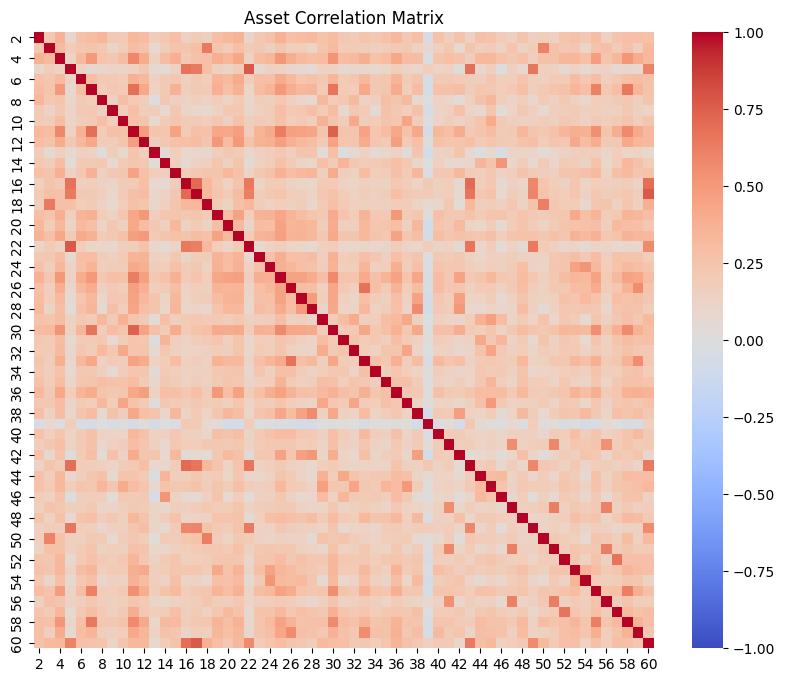

In [9]:
# Calculate daily returns (if the dataset is prices rather than returns, we calculate pct_change)
# If the dataset is already weights or returns, adjust accordingly. We assume it contains returns or we can compute them.
if any(isinstance(c, str) and 'price' in c.lower() for c in df.columns) or df.max().max() > 10:
    returns = df.pct_change().dropna()
else:
    # If the data is already returns
    returns = df

# Expected Returns (Annualized, assuming 252 trading days)
mean_returns = returns.mean() * 252

# Covariance Matrix (Annualized)
cov_matrix = returns.cov() * 252

# Assuming risk-free rate is roughly 0% for Sharpe calculation on individual assets
individual_sharpe = mean_returns / (returns.std() * np.sqrt(252))

print("Top 5 assets by Sharpe Ratio:")
display(individual_sharpe.sort_values(ascending=False).head())

# Optional visualization of correlations
plt.figure(figsize=(10, 8))
sns.heatmap(returns.corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Asset Correlation Matrix")
plt.show()

## 4. Define Optimization Objective and Constraints
Set up the objective function (e.g., negative Sharpe ratio to minimize) and define constraints for the SLSQP optimizer, including the sum of weights equaling 100% and a specific boundary constraint setting a maximum of 10% for the risk-free asset.

In [10]:
# Risk free rate (assumed)
rf_rate = 0.02 

def portfolio_annualised_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * weights)
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return std, returns

def neg_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    p_var, p_ret = portfolio_annualised_performance(weights, mean_returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_var

# Number of assets
num_assets = len(mean_returns)

# Constraints: Sum of weights = 1
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Bounds for each asset
# Assuming the first asset in the dataframe (or a designated one) is the risk-free asset
# To generalize, we will bound all risky assets between 0 and 1 (long only)
# And the risk free asset between 0 and 0.10. Let's assume asset 'RF' is the risk free asset.
# If there's no explicitly named 'RF' asset, we assume the user might designate an index. 
# Here we will cap the first asset just as an example of setting a 10% max on a single asset.
# (Update index 0 to the actual risk-free column index if you have one specifically named)

risk_free_asset_idx = 0 
bounds = tuple((0, 0.10) if i == risk_free_asset_idx else (0, 1) for i in range(num_assets))

# Initial guess: equally distributed
init_guess = num_assets * [1. / num_assets,]

## 5. Run SLSQP Portfolio Optimization
Execute `scipy.optimize.minimize` using the SLSQP method to find the optimal weights for the custom portfolio based on the defined objective and boundary constraints.

In [11]:
# Perform the optimization
opt_results = sco.minimize(neg_sharpe_ratio, init_guess, args=(mean_returns, cov_matrix, rf_rate),
                           method='SLSQP', bounds=bounds, constraints=constraints)

if opt_results.success:
    print("Optimization Successful!")
else:
    print("Optimization Failed:\n", opt_results.message)

optimal_weights = opt_results.x
optimal_weights = np.round(optimal_weights, 4)

Optimization Successful!


## 6. Analyze Optimized Portfolio
Calculate the expected return, volatility, and Sharpe ratio of the newly optimized portfolio. Visualize the final asset allocation weights.

----------------------------------------
Optimized Portfolio Performance
----------------------------------------
Expected Annualized Return: 24.80%
Annualized Volatility: 14.27%
Sharpe Ratio: 1.5977

Asset Allocations:


,Weight
51,0.3121
56,0.2384
50,0.1307
22,0.0787
48,0.0778
43,0.0744
47,0.0541
41,0.0339


<Figure size 1000x600 with 0 Axes>

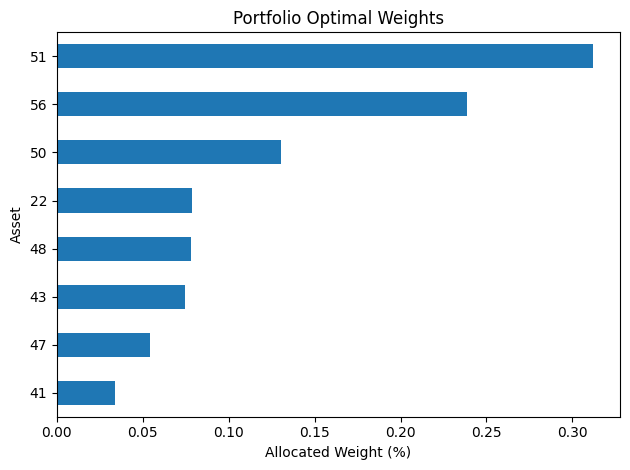

In [12]:
opt_std, opt_ret = portfolio_annualised_performance(optimal_weights, mean_returns, cov_matrix)
opt_sharpe = (opt_ret - rf_rate) / opt_std

print("-" * 40)
print("Optimized Portfolio Performance")
print("-" * 40)
print(f"Expected Annualized Return: {opt_ret:.2%}")
print(f"Annualized Volatility: {opt_std:.2%}")
print(f"Sharpe Ratio: {opt_sharpe:.4f}")

# Filter out zero weights for the pie chart
allocations = pd.DataFrame(data={'Weight': optimal_weights}, index=returns.columns)
positive_allocations = allocations[allocations['Weight'] > 0.001]

print("\nAsset Allocations:")
display(positive_allocations.sort_values(by="Weight", ascending=False))

# Plot allocations
plt.figure(figsize=(10, 6))
positive_allocations.sort_values(by="Weight").plot(kind='barh', legend=False, title='Portfolio Optimal Weights')
plt.xlabel('Allocated Weight (%)')
plt.ylabel('Asset')
plt.tight_layout()
plt.show()

## 8. Visualize Risk-Return for ALL Assets
Instead of isolating 3 assets, this section plots the Annualized Volatility vs Expected Return for **all 60 assets** you have. It also plots a large sample of random valid portfolios across the entire dataset to visualize the overall opportunity set and the approximate efficient frontier boundary!

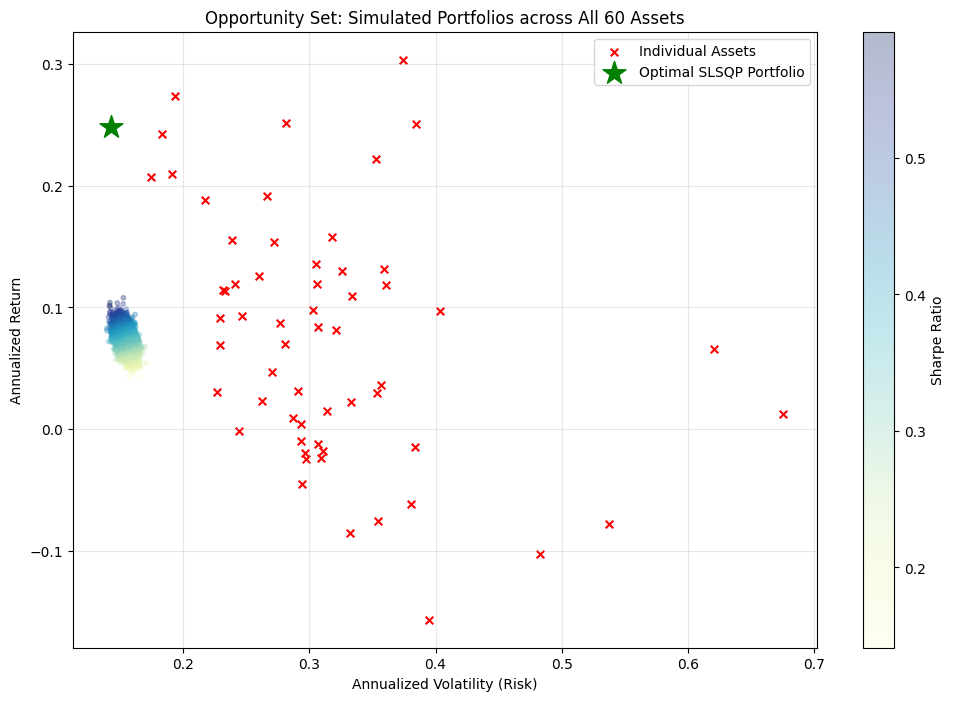

In [15]:
# Number of random portfolios to simulate
num_portfolios = 10000

results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    # Generate random weights for all assets
    w = np.random.random(num_assets)
    w /= np.sum(w)  # normalize to sum to 1
    weights_record.append(w)
    
    # Calculate expected return and volatility for the random portfolio
    p_var, p_ret = portfolio_annualised_performance(w, mean_returns, cov_matrix)
    p_std = p_var
    
    # Store results (Return, Volatility, Sharpe Ratio)
    results[0, i] = p_std
    results[1, i] = p_ret
    results[2, i] = (p_ret - rf_rate) / p_std

# Plotting the simulated portfolios
plt.figure(figsize=(12, 8))
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='YlGnBu', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')

# Plot the individual 60 assets as reference points
sigma_ann = returns.std() * np.sqrt(252)
plt.scatter(sigma_ann, mean_returns, color='red', marker='x', s=30, label='Individual Assets')

# Highlight the optimized portfolio we found earlier with SLSQP
plt.scatter(opt_std, opt_ret, color='green', marker='*', s=300, label='Optimal SLSQP Portfolio')

plt.title('Opportunity Set: Simulated Portfolios across All 60 Assets')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

## 9. Top Performing Assets Summary
A structured table summarizing the top performing assets across the entire dataset, sorted descending by their standalone Sharpe Ratio.

In [17]:
# Create a centralized DataFrame with individual asset performance stats
asset_performance = pd.DataFrame({
    'Expected Return (Ann.)': mean_returns,
    'Volatility (Ann.)': sigma_ann,
    'Sharpe Ratio': individual_sharpe
})

# Sort them to find the top performers based on the best reward-to-risk ratio
top_assets = asset_performance.sort_values(by='Sharpe Ratio', ascending=False)

print(f"Top 15 Best Performing Assets out of {num_assets} (ranked by Sharpe Ratio):")
display(top_assets.head(15).style.format({
    'Expected Return (Ann.)': '{:.2%}',
    'Volatility (Ann.)': '{:.2%}',
    'Sharpe Ratio': '{:.4f}'
}).background_gradient(subset=['Sharpe Ratio'], cmap='Greens'))

Top 15 Best Performing Assets out of 59 (ranked by Sharpe Ratio):


,Expected Return (Ann.),Volatility (Ann.),Sharpe Ratio
51,27.34%,19.37%,1.4116
56,24.21%,18.30%,1.3227
47,20.70%,17.47%,1.1851
41,20.98%,19.14%,1.0964
43,25.09%,28.15%,0.8913
50,18.81%,21.72%,0.8659
22,30.32%,37.44%,0.8097
16,19.13%,26.64%,0.7183
48,25.06%,38.43%,0.6522
18,15.52%,23.87%,0.6504


## 10. Robustness Check: Rolling Window SLSQP Optimization (70 Periods)
To verify the robustness of each asset's assigned weights over time, we use a rolling window approach. We calculate the optimal portfolio using the SLSQP method for a rolling period of exactly 70 rows (e.g., moving from 1-70, then 2-71, 3-72, up until the end of the dataset). This shows us how sensitive the weights are to shifts in the time-series data.

Starting rolling window optimization (Window Size: 70, Total Periods: 1758)...
Completed 1689 successful rolling window optimizations.


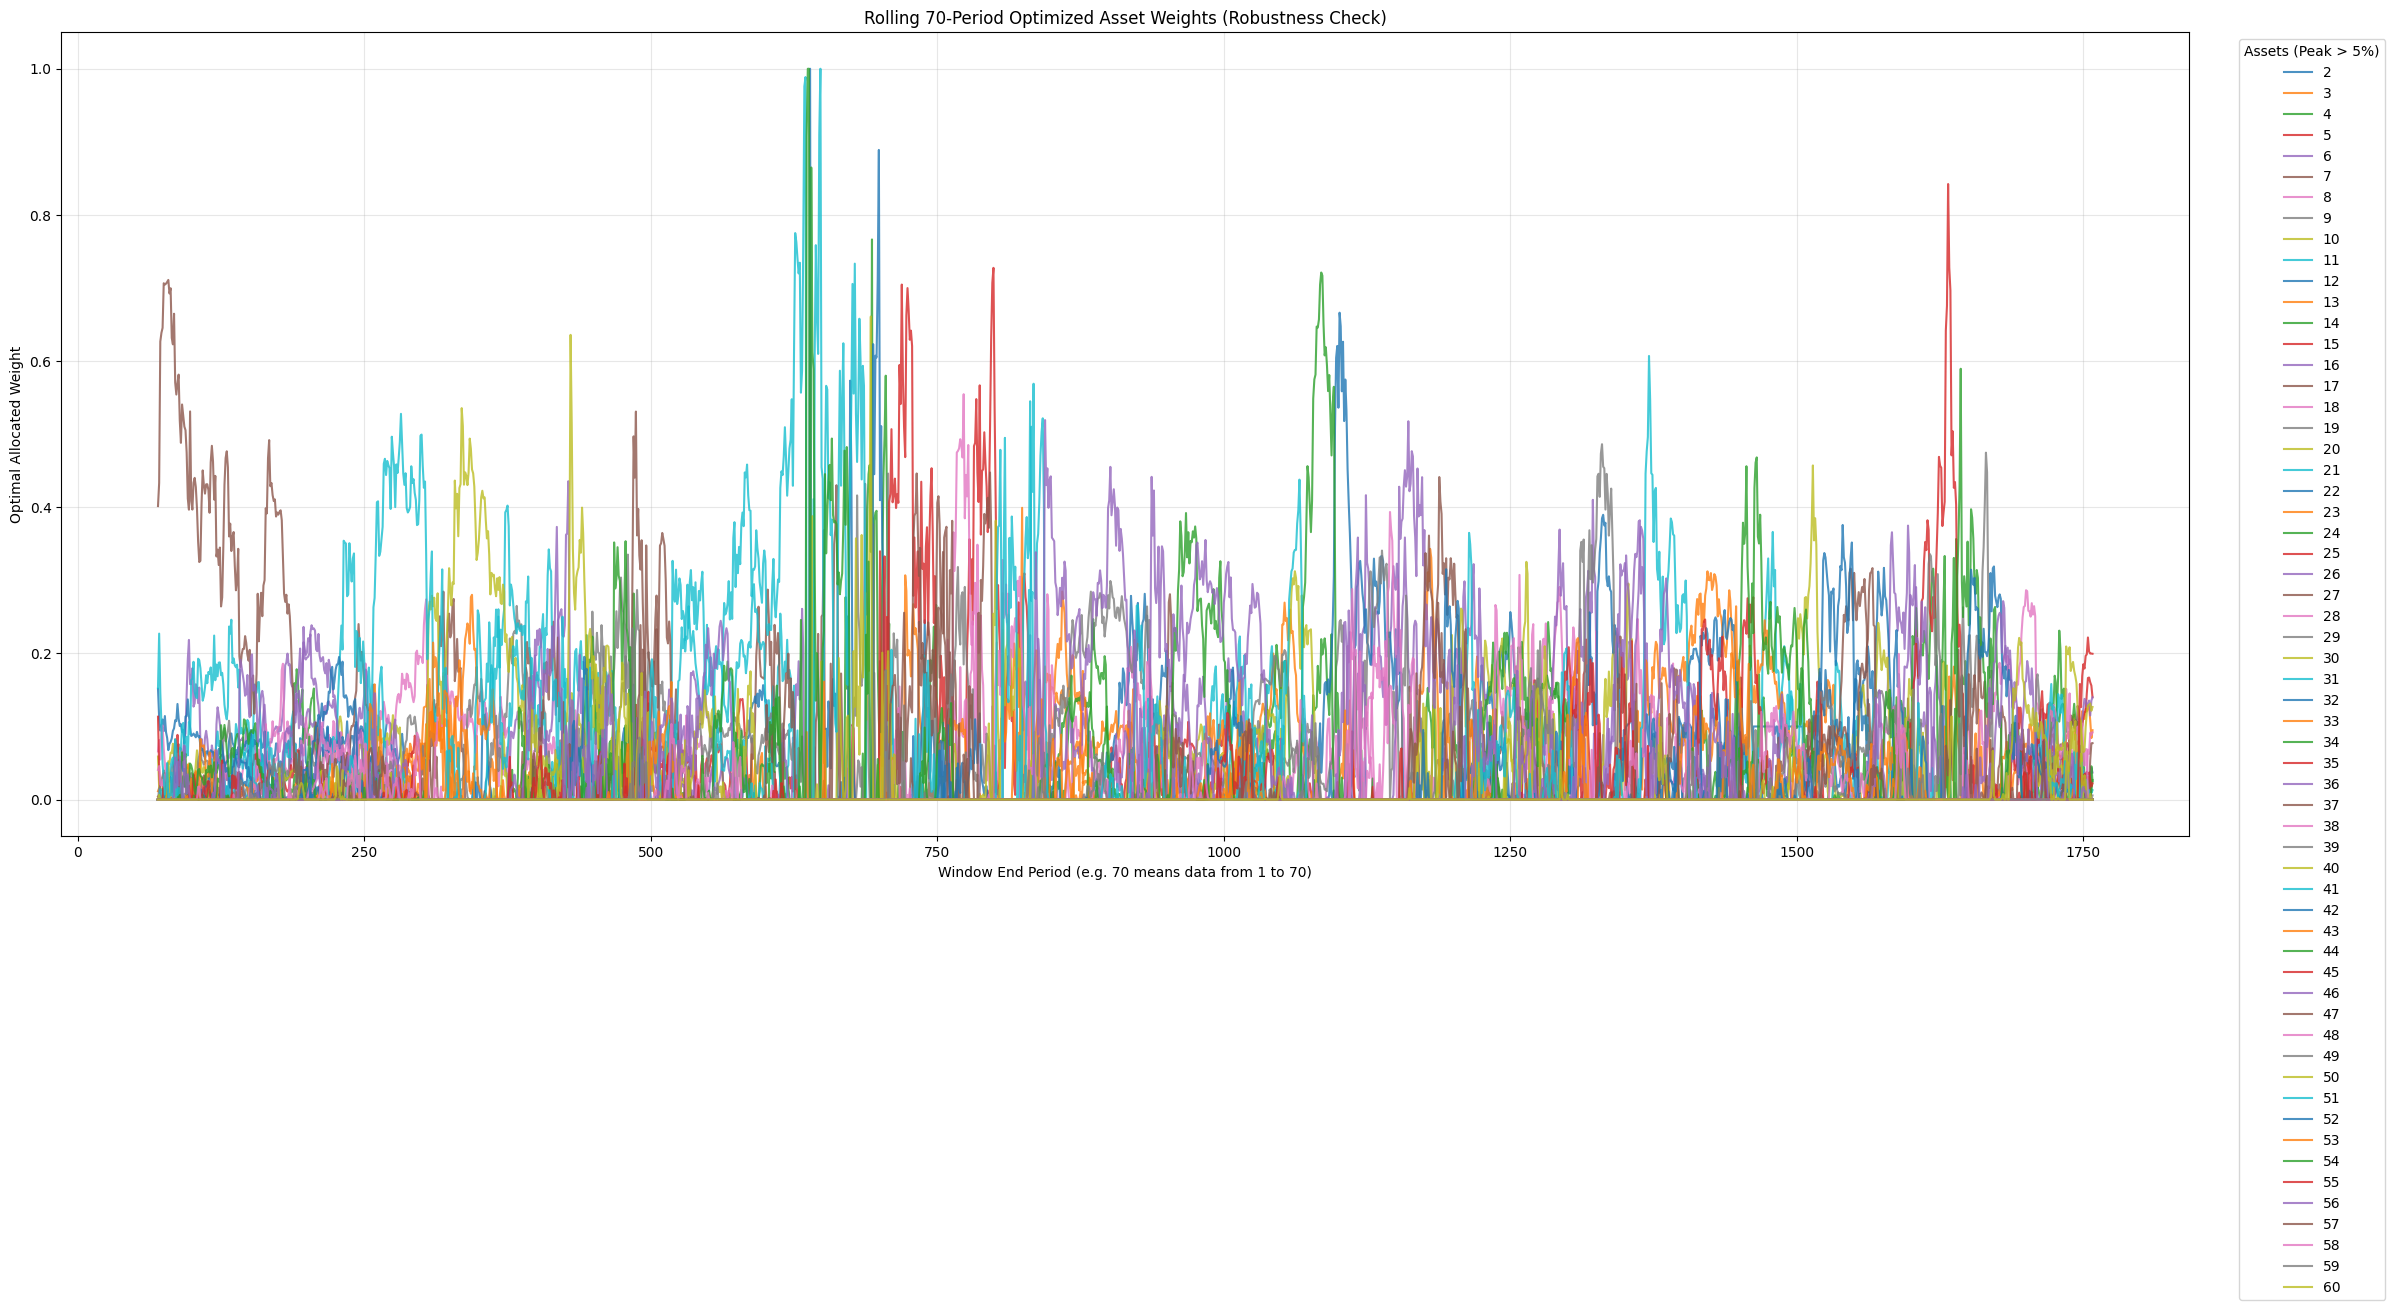

In [22]:
window_size = 70
num_periods = len(returns)

rolling_weights = []
window_end_labels = []

print(f"Starting rolling window optimization (Window Size: {window_size}, Total Periods: {num_periods})...")

for i in range(num_periods - window_size + 1):
    # Slice the dataframe to grab exactly 70 periods
    window_data = returns.iloc[i : i + window_size]
    
    # Calculate means and covariance for this specific window
    w_mean_returns = window_data.mean() * 252
    w_cov_matrix = window_data.cov() * 252
    
    # Run the SLSQP optimization for this window
    res = sco.minimize(
        neg_sharpe_ratio, 
        init_guess, 
        args=(w_mean_returns, w_cov_matrix, rf_rate),
        method='SLSQP', 
        bounds=bounds, 
        constraints=constraints
    )
    
    if res.success:
        rolling_weights.append(res.x)
        # Record the period ending label (either Datetime or integer index)
        window_end_labels.append(i + window_size)

print(f"Completed {len(rolling_weights)} successful rolling window optimizations.")

# Convert to DataFrame for easy analysis and plotting
rolling_weights_df = pd.DataFrame(rolling_weights, index=window_end_labels, columns=returns.columns)

# Visualizing the weight fluctuations
plt.figure(figsize=(24, 12))

# Filter to keep the plot legible: only show assets that reached at least a 5% allocation at some point
significant_assets_rolling = rolling_weights_df.columns[rolling_weights_df.max() > 0.05]

rolling_weights_df[significant_assets_rolling].plot(ax=plt.gca(), linewidth=1.5, alpha=0.8)

plt.title(f"Rolling {window_size}-Period Optimized Asset Weights (Robustness Check)")
plt.xlabel("Window End Period (e.g. 70 means data from 1 to 70)")
plt.ylabel("Optimal Allocated Weight")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Assets (Peak > 5%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Asset Volatilities and Custom Sector Portfolios
Because the dataset only provides numerical column labels (2, 3, 4, etc.) without explicit asset names or sectors, we can statistically infer the **risk-free asset** by finding the asset with the lowest volatility (closest to 0).

For **Oil and Gas** and **Health Care**, you will need to map the asset IDs (column numbers) if you know them from an external reference. Below is the volatility mapped per asset, followed by a cell to build a portfolio on specific custom assets.

In [27]:
# 1. Calculate and Sort the Volatility of All Assets
# The asset with the lowest volatility is typically the risk-free asset
asset_volatilities = (returns.std() * np.sqrt(252)).sort_values()

print("Asset Volatilities (from Lowest to Highest):")
print("*" * 50)
# Use .to_string() to print all 60 assets instead of just .head(10)
print(asset_volatilities.to_string()) 
print("*" * 50)

inferred_rf_asset = asset_volatilities.index[0]
print(f"-> The inferred Risk-Free Asset is likely Column: {inferred_rf_asset} (Volatility: {asset_volatilities.iloc[0]:.4f})")

# 2. Custom Sector Portfolio Optimization
# Replace these lists with the actual column numbers for Oil & Gas and Health Care from your reference material.
# Included the inferred risk-free asset in the portfolio.
oil_and_gas_assets = [10, 12, 15] # Example IDs
healthcare_assets = [20, 22, 25]  # Example IDs
risk_free_asset = [inferred_rf_asset]

# Combine all desired assets for the targeted portfolio
target_assets = oil_and_gas_assets + healthcare_assets + risk_free_asset

# Ensure columns exist in dataset
target_assets = [col for col in target_assets if col in returns.columns]

if len(target_assets) > 1:
    print(f"\nRunning Optimization for custom assets: {target_assets}")
    
    # Filter returns and metrics for only these assets
    target_returns = returns[target_assets]
    t_mean_returns = target_returns.mean() * 252
    t_cov_matrix = target_returns.cov() * 252
    
    # Redefine bounds mapping: max 10% for the inferred risk-free asset, long-only (0 to 1) for the rest
    t_bounds = tuple((0, 0.10) if asset == inferred_rf_asset else (0, 1) for asset in target_assets)
    t_init_guess = len(target_assets) * [1. / len(target_assets)]
    t_constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    
    # Optimize
    res_custom = sco.minimize(
        neg_sharpe_ratio, 
        t_init_guess, 
        args=(t_mean_returns, t_cov_matrix, rf_rate),
        method='SLSQP', 
        bounds=t_bounds, 
        constraints=t_constraints
    )
    
    if res_custom.success:
        print("\nCustom Portfolio Optimal Weights:")
        custom_weights = pd.DataFrame({'Weight': res_custom.x}, index=target_assets)
        display(custom_weights.sort_values(by="Weight", ascending=False).style.format({'Weight': '{:.2%}'}))
        
        print("\n" + "="*60)
        print("ALL 60 ASSET WEIGHTS FOR CHALLENGE SUBMISSION (COPY/PASTE BELOW):")
        print("="*60)
        
        # Create a series with 0.0 for all originally found columns
        submission_weights = pd.Series(0.0, index=returns.columns)
        
        # Insert the optimized weights only for the targeted active assets
        submission_weights[target_assets] = res_custom.x
        
        # Format output safely as a comma-separated list or just space-separated plain values
        print("Columns Context:", list(submission_weights.index))
        print("Values to Paste:", np.round(submission_weights.values, 6).tolist())
        
    else:
        print("Optimization failed for the custom portfolio.")
else:
    print("Not enough custom assets found in the dataset.")

Asset Volatilities (from Lowest to Highest):
**************************************************
47    0.174693
56    0.183033
41    0.191392
51    0.193692
50    0.217200
54    0.227083
29    0.228993
44    0.229129
17    0.231134
58    0.233006
18    0.238675
60    0.241275
31    0.244324
36    0.246276
53    0.259898
14    0.262561
16    0.266386
46    0.270597
7     0.271777
21    0.276941
35    0.280296
43    0.281545
4     0.286949
34    0.290742
2     0.292953
45    0.293244
59    0.294252
25    0.296119
57    0.297046
3     0.302918
24    0.305199
55    0.305692
32    0.306921
11    0.307211
37    0.309209
27    0.310687
52    0.314035
12    0.318100
8     0.321382
6     0.325936
10    0.332072
19    0.333274
40    0.333531
5     0.353118
20    0.353358
38    0.354014
30    0.356553
49    0.359086
33    0.360483
22    0.374434
26    0.380933
15    0.384068
48    0.384322
23    0.394618
39    0.403170
28    0.483124
42    0.537733
9     0.620573
13    0.675537
*******************

,Weight
22,61.23%
12,28.77%
47,10.00%
10,0.00%
25,0.00%
15,0.00%
20,0.00%



ALL 60 ASSET WEIGHTS FOR CHALLENGE SUBMISSION (COPY/PASTE BELOW):
Columns Context: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
Values to Paste: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.287698, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.612302, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


Starting rolling window optimization for custom assets (Window Size: 70, Total Periods: 1758)...
Completed 1689 successful rolling window optimizations.


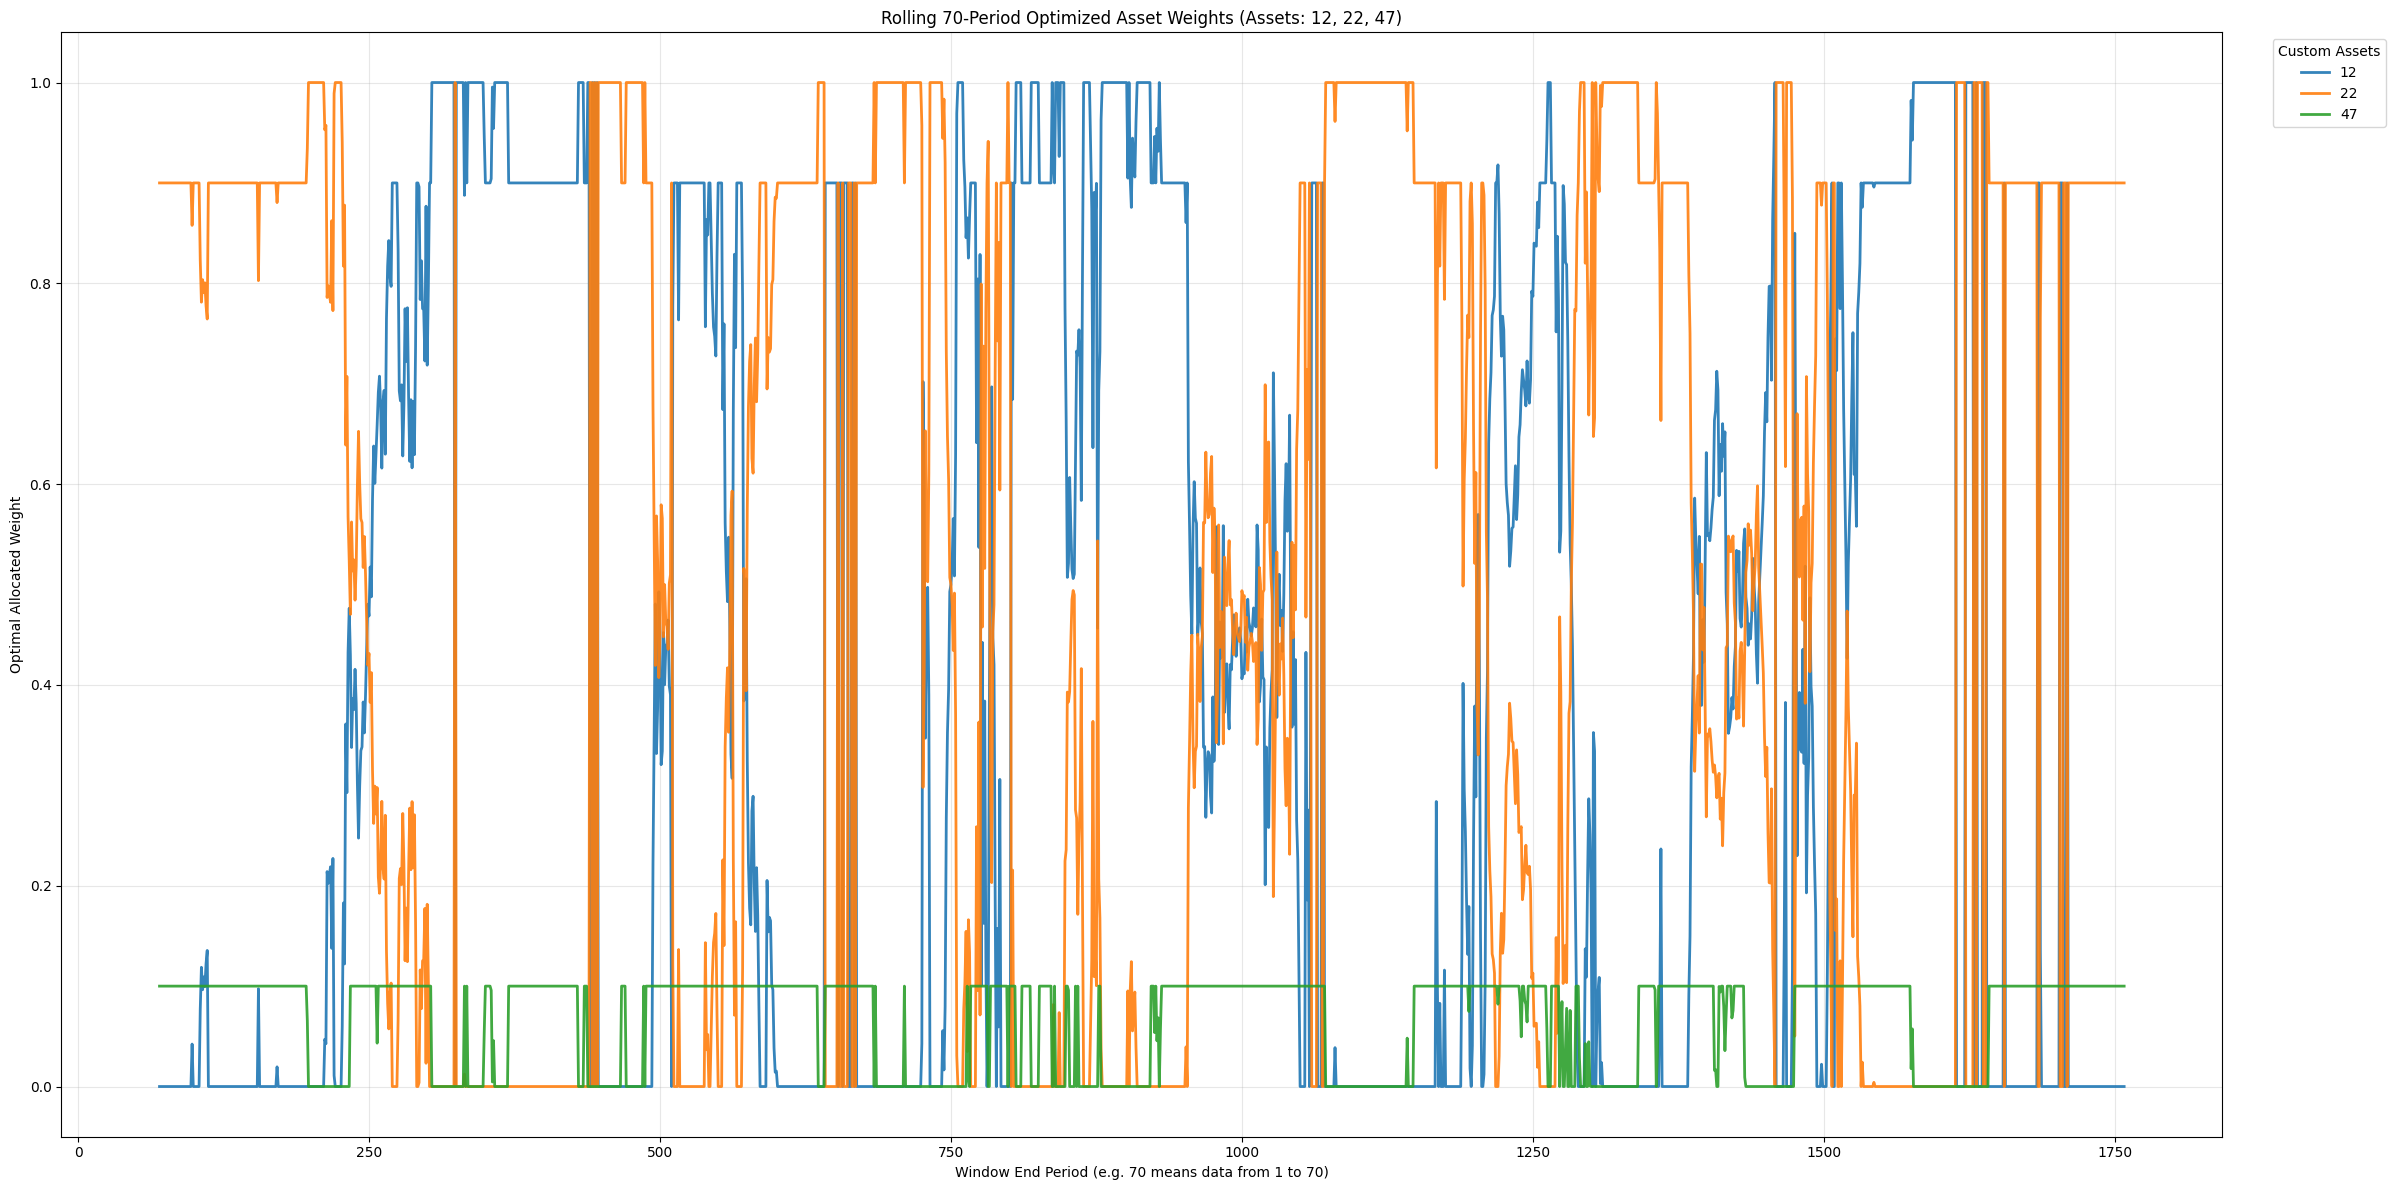

In [25]:
# The 3 specific assets we are analyzing
selected_assets = [12, 22, 47]
risk_free_id = 47

window_size = 70
num_periods = len(returns)

rolling_weights = []
window_end_labels = []

print(f"Starting rolling window optimization for custom assets (Window Size: {window_size}, Total Periods: {num_periods})...")

# Filter returns for just the 3 chosen assets
target_returns = returns[selected_assets]

# Redefine constraints, bounds, and initial guess specifically for these 3 assets
t_bounds = tuple((0, 0.10) if asset == risk_free_id else (0, 1) for asset in selected_assets)
t_init_guess = len(selected_assets) * [1. / len(selected_assets)]
t_constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

for i in range(num_periods - window_size + 1):
    # Slice the targeted dataframe to grab exactly 70 periods
    window_data = target_returns.iloc[i : i + window_size]
    
    # Calculate means and covariance for this specific window
    w_mean_returns = window_data.mean() * 252
    w_cov_matrix = window_data.cov() * 252
    
    # Run the SLSQP optimization for this window
    res = sco.minimize(
        neg_sharpe_ratio, 
        t_init_guess, 
        args=(w_mean_returns, w_cov_matrix, rf_rate),
        method='SLSQP', 
        bounds=t_bounds, 
        constraints=t_constraints
    )
    
    if res.success:
        rolling_weights.append(res.x)
        # Record the period ending label 
        window_end_labels.append(i + window_size)

print(f"Completed {len(rolling_weights)} successful rolling window optimizations.")

# Convert to DataFrame for easy analysis and plotting using the selected assets columns
rolling_weights_df = pd.DataFrame(rolling_weights, index=window_end_labels, columns=selected_assets)

# Visualizing the weight fluctuations
plt.figure(figsize=(24, 12))

# Plot all 3 assets (no need to filter since we only have 3)
rolling_weights_df.plot(ax=plt.gca(), linewidth=2.0, alpha=0.9)

plt.title(f"Rolling {window_size}-Period Optimized Asset Weights (Assets: 12, 22, 47)")
plt.xlabel("Window End Period (e.g. 70 means data from 1 to 70)")
plt.ylabel("Optimal Allocated Weight")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Custom Assets")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()